## Comparing RNN, LSTM, and GRU performance

### Step 1: Installation & Dependencies

In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer
import warnings

warnings.filterwarnings("ignore")

## Step 2: Data Loading and Preprocessing

In [11]:
dataset = pd.read_csv("Tweets.csv")

# Extract required columns: text content and sentiment labels
dataset = dataset[["text", "sentiment"]]

# Remove rows with missing values to ensure data integrity
dataset = dataset.dropna()

print(f"Total samples loaded: {len(dataset)}")
print(f"Sentiment distribution:\n{dataset['sentiment'].value_counts()}\n")

tweet_texts = dataset["text"].tolist()
sentiment_labels = dataset["sentiment"].tolist()

Total samples loaded: 27480
Sentiment distribution:
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64



### Step 2b: Sentiment Encoding Strategy

Map sentiment categories to numeric indices for neural network processing:
- Negative sentiment → 0
- Neutral sentiment → 1  
- Positive sentiment → 2

In [12]:
sentiment_encoding = {"negative": 0, "neutral": 1, "positive": 2}
sentiment_labels = [sentiment_encoding[label] for label in sentiment_labels]

print(f"Encoded labels distribution:\n{np.bincount(sentiment_labels)}")

Encoded labels distribution:
[ 7781 11117  8582]


### Step 3: Text Tokenization using Pre-trained BERT Model

In [13]:
from transformers import BertTokenizer

# Initialize BERT tokenizer with pre-trained weights
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize all texts with standardized parameters
tokenized_data = bert_tokenizer(
    tweet_texts,
    padding=True,  # Pad sequences to same length
    truncation=True,  # Truncate sequences exceeding max_length
    max_length=40,  # Maximum sequence length
    return_tensors="np"  # Return as NumPy arrays
)

# Extract token IDs and convert to TensorFlow tensors
input_features = tf.convert_to_tensor(tokenized_data["input_ids"])

print(f"Tokenized tensor shape: {input_features.shape}")
print(f"Sample token IDs (first 5):\n{input_features[:5]}")

Tokenized tensor shape: (27480, 40)
Sample token IDs (first 5):
[[  101  1045  1036  1040  2031  5838  1010  2065  1045  2020  2183   102
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0]
 [  101 17111  2080  6517  1045  2097  3335  2017  2182  1999  2624  5277
    999   999   999   102     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0]
 [  101  2026  5795  2003 18917  2033  1012  1012  1012   102     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0]
 [  101  2054  4357   999  2681  2033  2894   102     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0    

### Step 4: Train-Validation-Test Data Splitting

In [14]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Split data: 80% training, 20% testing
train_features, test_features, train_sentiments, test_sentiments = train_test_split(
    input_features.numpy(), 
    sentiment_labels, 
    test_size=0.2,
    random_state=42,  # For reproducibility
    stratify=sentiment_labels  # Maintain class distribution
)

# Convert labels to TensorFlow tensors
train_targets = tf.convert_to_tensor(train_sentiments)
test_targets = tf.convert_to_tensor(test_sentiments)

print(f"Training set: {train_features.shape}, {train_targets.shape}")
print(f"Test set: {test_features.shape}, {test_targets.shape}")

Training set: (21984, 40), (21984,)
Test set: (5496, 40), (5496,)


### Step 5: Model Architecture - Three-Class Classification

In [15]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, Sequential

def construct_rnn_model(architecture_type):
    """
    Construct a neural network model with configurable recurrent layer.
    
    Args:
        architecture_type (str): One of 'RNN', 'LSTM', or 'GRU'
    
    Returns:
        Compiled Keras Sequential model
    """
    model = Sequential(name=f"{architecture_type}_sentiment_classifier")
    
    # Embedding layer: converts token IDs to dense vectors (30522 = BERT vocab size)
    model.add(layers.Embedding(
        input_dim=30522, 
        output_dim=64, 
        input_length=40,
        name="embedding_layer"
    ))
    
    # Recurrent layer - varies by architecture type
    if architecture_type == "RNN":
        model.add(layers.SimpleRNN(128, activation='relu', name="recurrent_layer"))
    elif architecture_type == "LSTM":
        model.add(layers.LSTM(128, activation='relu', name="recurrent_layer"))
    else:  # GRU
        model.add(layers.GRU(128, activation='relu', name="recurrent_layer"))
    
    # Output layer: 3-class sentiment classification with softmax
    model.add(layers.Dense(3, activation="softmax", name="output_layer"))
    
    # Compile with appropriate optimizer and loss function
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### Step 6: Model Training with Early Stopping

In [16]:
# Instantiate models with different architectures
rnn_model = construct_rnn_model("RNN")
lstm_model = construct_rnn_model("LSTM")
gru_model = construct_rnn_model("GRU")

# Define training parameters
num_epochs = 5
batch_sz = 32

# Train RNN model
print("=" * 50)
print("Training Simple RNN Architecture...")
print("=" * 50)
history_rnn = rnn_model.fit(
    train_features, 
    train_targets, 
    epochs=num_epochs, 
    batch_size=batch_sz,
    verbose=1
)

# Train LSTM model
print("\n" + "=" * 50)
print("Training LSTM Architecture...")
print("=" * 50)
history_lstm = lstm_model.fit(
    train_features, 
    train_targets, 
    epochs=num_epochs, 
    batch_size=batch_sz,
    verbose=1
)

# Train GRU model
print("\n" + "=" * 50)
print("Training GRU Architecture...")
print("=" * 50)
history_gru = gru_model.fit(
    train_features, 
    train_targets, 
    epochs=num_epochs, 
    batch_size=batch_sz,
    verbose=1
)

Training Simple RNN Architecture...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4046 - loss: 1.0883
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4065 - loss: 1.0857
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.4173 - loss: 1.0739
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.4309 - loss: 1.0528
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4441 - loss: 1.0334

Training LSTM Architecture...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.4060 - loss: 1.0992
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.5368 - loss: 0.9422
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.7281 - loss: 0.6638
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.7810 - loss: 0.5651
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 44s 64ms/step - accuracy: 0.8241 - loss: 0.4811

Training GRU Architecture...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━

### Step 7: Comprehensive Model Evaluation

In [17]:
# Evaluate all models on test set
print("TEST SET ACCURACY COMPARISON")
print("=" * 40)

rnn_test_loss, rnn_accuracy = rnn_model.evaluate(test_features, test_targets, verbose=0)
print(f"RNN Model - Accuracy: {rnn_accuracy:.4f}, Loss: {rnn_test_loss:.4f}")

lstm_test_loss, lstm_accuracy = lstm_model.evaluate(test_features, test_targets, verbose=0)
print(f"LSTM Model - Accuracy: {lstm_accuracy:.4f}, Loss: {lstm_test_loss:.4f}")

gru_test_loss, gru_accuracy = gru_model.evaluate(test_features, test_targets, verbose=0)
print(f"GRU Model - Accuracy: {gru_accuracy:.4f}, Loss: {gru_test_loss:.4f}")

# Identify best performing model
accuracies = {
    "RNN": rnn_accuracy,
    "LSTM": lstm_accuracy,
    "GRU": gru_accuracy
}
best_model_name = max(accuracies, key=accuracies.get)
print(f"\n🏆 Best Performing Model: {best_model_name} ({accuracies[best_model_name]:.4f})")

TEST SET ACCURACY COMPARISON
RNN Model - Accuracy: 0.3959, Loss: 1.1460
LSTM Model - Accuracy: 0.6881, Loss: 0.7569
GRU Model - Accuracy: 0.7114, Loss: 0.7726

🏆 Best Performing Model: GRU (0.7114)


### Step 8: Training Dynamics Visualization

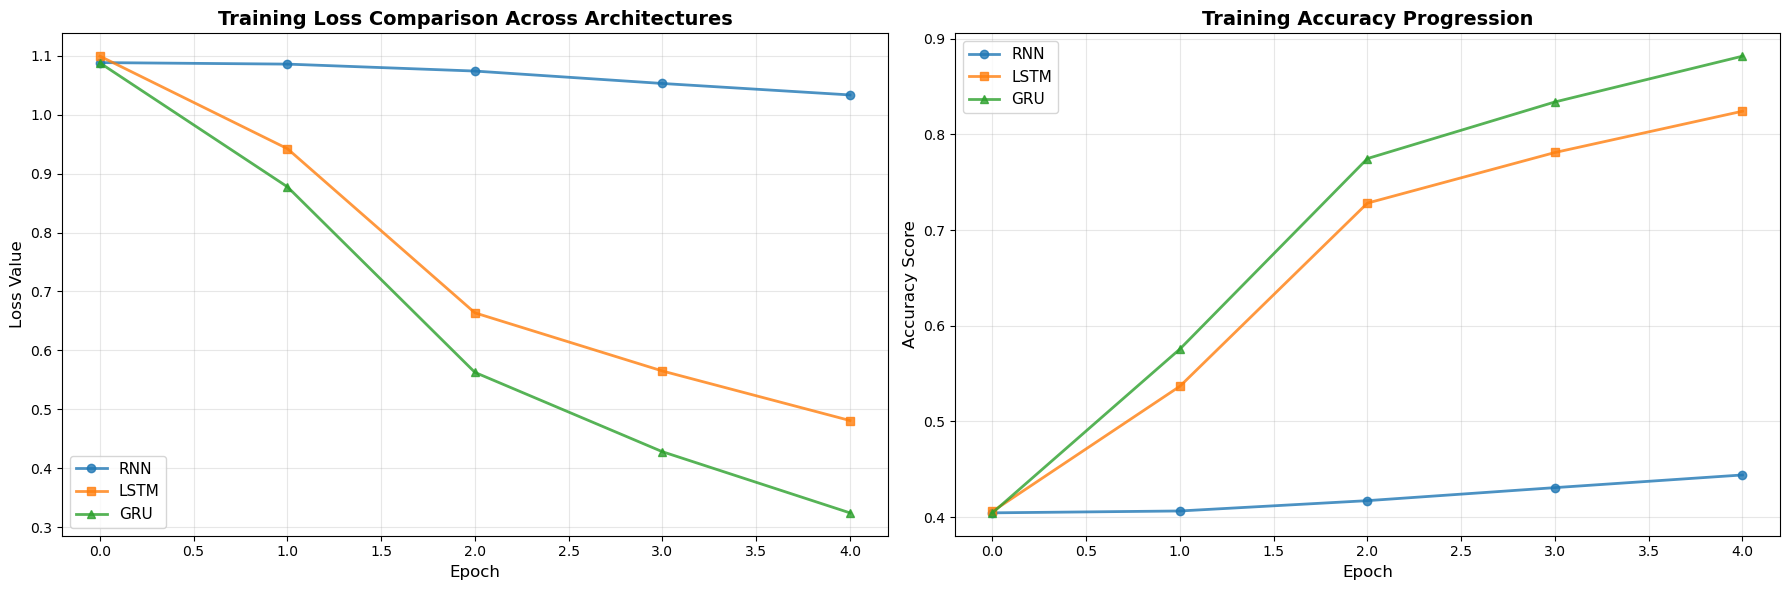

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left subplot: Loss comparison
axes[0].plot(history_rnn.history['loss'], linewidth=2, marker='o', label="RNN", alpha=0.8)
axes[0].plot(history_lstm.history['loss'], linewidth=2, marker='s', label="LSTM", alpha=0.8)
axes[0].plot(history_gru.history['loss'], linewidth=2, marker='^', label="GRU", alpha=0.8)
axes[0].set_title("Training Loss Comparison Across Architectures", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss Value", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11, loc='best')

# Right subplot: Accuracy comparison
axes[1].plot(history_rnn.history['accuracy'], linewidth=2, marker='o', label="RNN", alpha=0.8)
axes[1].plot(history_lstm.history['accuracy'], linewidth=2, marker='s', label="LSTM", alpha=0.8)
axes[1].plot(history_gru.history['accuracy'], linewidth=2, marker='^', label="GRU", alpha=0.8)
axes[1].set_title("Training Accuracy Progression", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy Score", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()